# 📊 EDA — Empleo por Sexo
**Fuente:** `e_por_sexo.csv`  
**Descripción:** Empleo dependiente privado mensual en Lima Metropolitana según sexo (Hombre, Mujer, No Especificado). Período 2015–2025.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130})
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'hombre': '#2980b9', 'mujer': '#e84393', 'no_esp': '#95a5a6'}
MES_ORDEN = {'ENE.':1,'FEB.':2,'MAR.':3,'ABR.':4,'MAY.':5,'JUN.':6,
             'JUL.':7,'AGO.':8,'SET.':9,'OCT.':10,'NOV.':11,'DIC.':12}
MESES_ETQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Set','Oct','Nov','Dic']
print('OK ✓')

OK ✓


## 1. Carga y Limpieza

In [3]:
df = pd.read_csv('e_por_sexo.csv', sep=';', encoding='utf-8', on_bad_lines='skip')
df.columns = df.columns.str.replace('\n', ' ', regex=False).str.strip()
df.columns = ['anio', 'mes', 'hombre', 'mujer', 'no_especificado']

for col in ['hombre', 'mujer', 'no_especificado']:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['hombre'], inplace=True)
df['anio'] = df['anio'].astype(int)
df['mes_num'] = df['mes'].map(MES_ORDEN)
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
df.sort_values('fecha', inplace=True)
df.reset_index(drop=True, inplace=True)
df['total'] = df['hombre'] + df['mujer'] + df['no_especificado']

print(f'Shape: {df.shape}')
df.head()

Shape: (128, 8)


,anio,mes,hombre,mujer,no_especificado,mes_num,fecha,total
0,2015,ENE.,2003550,994870,131935,1,2015-01-01,3130355
1,2015,FEB.,1987296,984469,146746,2,2015-02-01,3118511
2,2015,MAR.,1995567,1005420,169068,3,2015-03-01,3170055
3,2015,ABR.,2016825,1011433,183525,4,2015-04-01,3211783
4,2015,MAY.,2023166,1010173,185887,5,2015-05-01,3219226


## 2. Estadísticas Descriptivas

In [4]:
desc = df[['hombre','mujer','no_especificado','total']].describe().round(0)
desc.index = ['Conteo','Media','Desv. Est.','Mín','Q25','Mediana','Q75','Máx']
desc

,hombre,mujer,no_especificado,total
Conteo,128.0,128.0,128.0,128.0
Media,2196463.0,1228346.0,214145.0,3638953.0
Desv. Est.,179779.0,156088.0,41049.0,369698.0
Mín,1683575.0,953077.0,131935.0,2810882.0
Q25,2068220.0,1105336.0,175468.0,3351678.0
Mediana,2166226.0,1184736.0,220535.0,3556945.0
Q75,2315176.0,1357536.0,247355.0,3919678.0
Máx,2603016.0,1572257.0,283142.0,4454406.0


In [5]:
print('Rango:', df['fecha'].min().strftime('%b %Y'), '→', df['fecha'].max().strftime('%b %Y'))

# Brecha de género promedio
brecha_mean = (df['hombre'] - df['mujer']).mean()
ratio_mean = (df['mujer'] / df['hombre']).mean()
print(f'Brecha promedio Hombre-Mujer: {brecha_mean:,.0f} trabajadores')
print(f'Ratio promedio Mujer/Hombre: {ratio_mean:.3f}')

Rango: Jan 2015 → Aug 2025
Brecha promedio Hombre-Mujer: 968,118 trabajadores
Ratio promedio Mujer/Hombre: 0.557


## 3. Serie de Tiempo — Empleo por Sexo

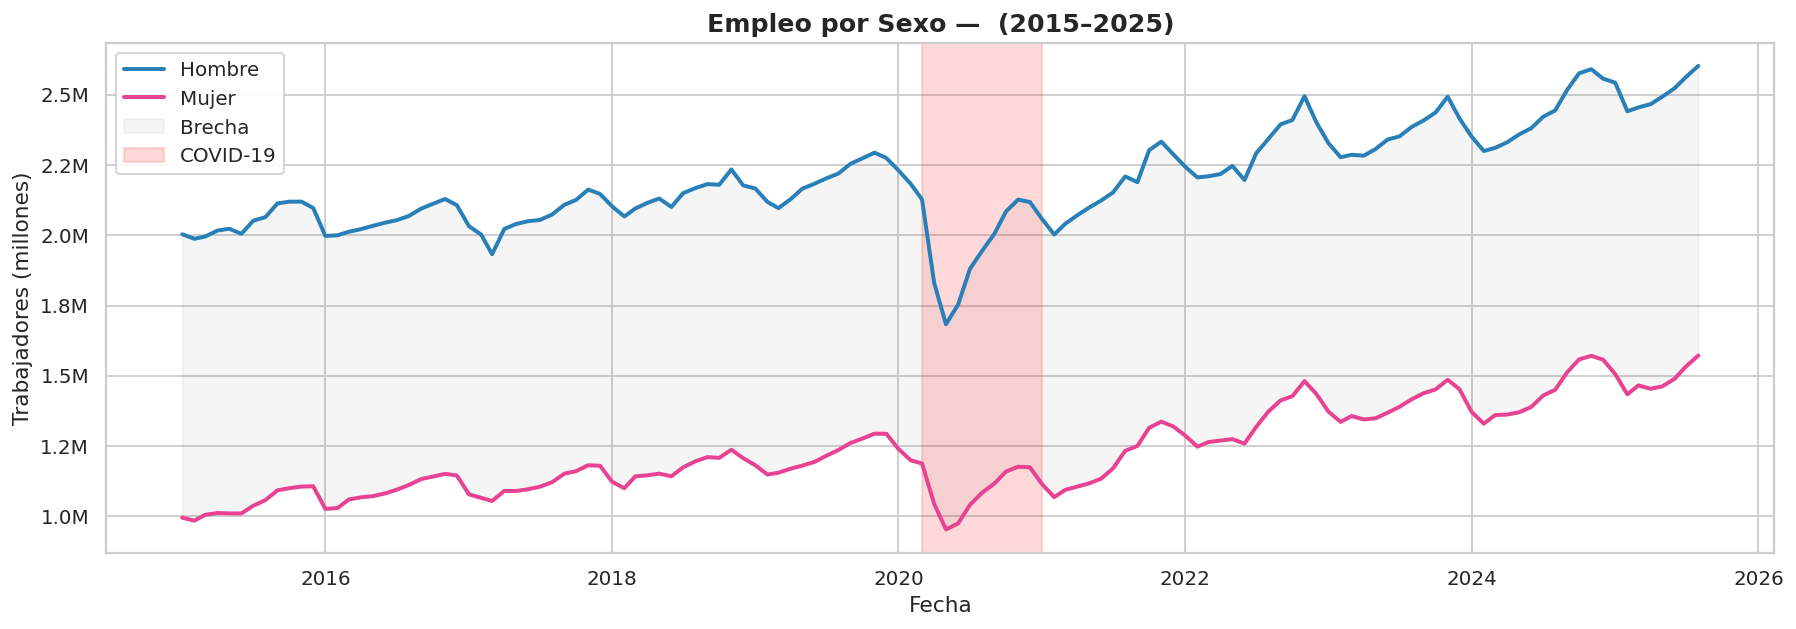

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['fecha'], df['hombre']/1e6, label='Hombre', color=COLORS['hombre'], lw=2.2)
ax.plot(df['fecha'], df['mujer']/1e6, label='Mujer', color=COLORS['mujer'], lw=2.2)
ax.fill_between(df['fecha'], df['mujer']/1e6, df['hombre']/1e6, alpha=0.08, color='gray', label='Brecha')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='red', label='COVID-19')
ax.set_title('Empleo por Sexo —  (2015–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## 4. Participación Porcentual Hombre vs Mujer

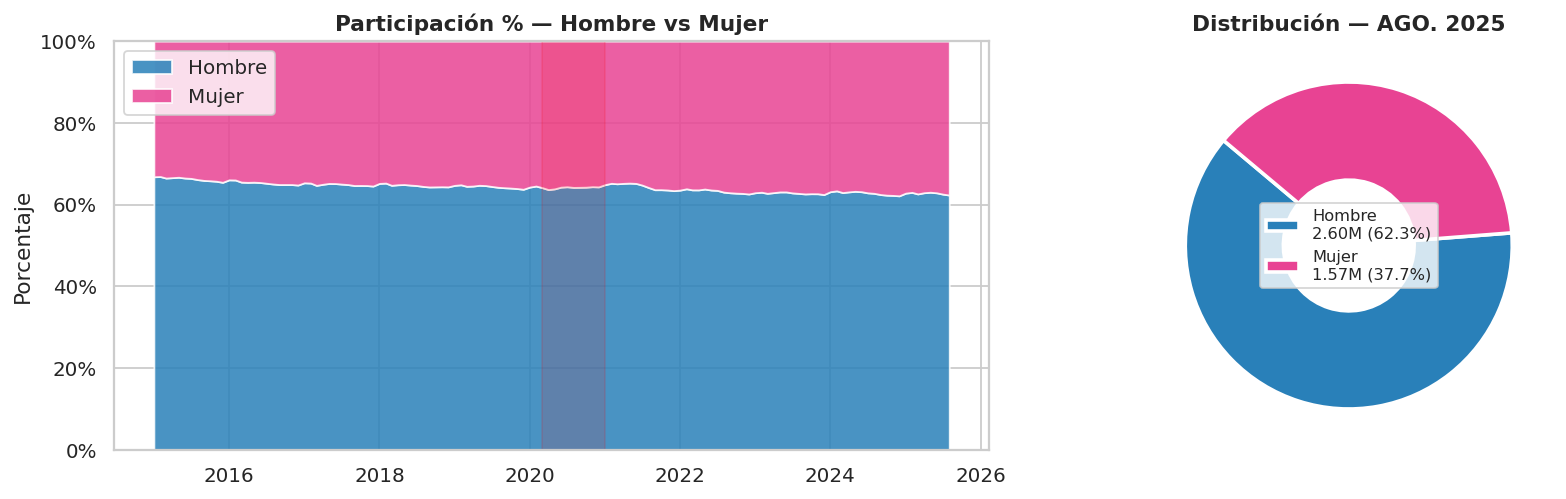

In [8]:
df['total_2cat'] = df['hombre'] + df['mujer']
df['pct_hombre'] = df['hombre'] / df['total_2cat'] * 100
df['pct_mujer'] = df['mujer'] / df['total_2cat'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Área apilada
axes[0].stackplot(df['fecha'], df['pct_hombre'], df['pct_mujer'],
                  labels=['Hombre', 'Mujer'],
                  colors=[COLORS['hombre'], COLORS['mujer']], alpha=0.85)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.12, color='red')
axes[0].set_title('Participación % — Hombre vs Mujer', fontweight='bold')
axes[0].set_ylabel('Porcentaje')
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(loc='upper left')

# Donut último mes
ultimo = df.iloc[-1]
sizes = [ultimo['hombre'], ultimo['mujer']]
labels = [f'Hombre\n{sizes[0]/1e6:.2f}M ({100*sizes[0]/sum(sizes):.1f}%)',
          f'Mujer\n{sizes[1]/1e6:.2f}M ({100*sizes[1]/sum(sizes):.1f}%)']
wedges, texts = axes[1].pie(sizes, colors=[COLORS['hombre'], COLORS['mujer']],
                             startangle=140, wedgeprops={'edgecolor':'white','linewidth':2, 'width':0.6})
axes[1].legend(wedges, labels, loc='center', fontsize=9)
axes[1].set_title(f'Distribución — {ultimo["mes"]} {int(ultimo["anio"])}', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Brecha de Género en el Tiempo

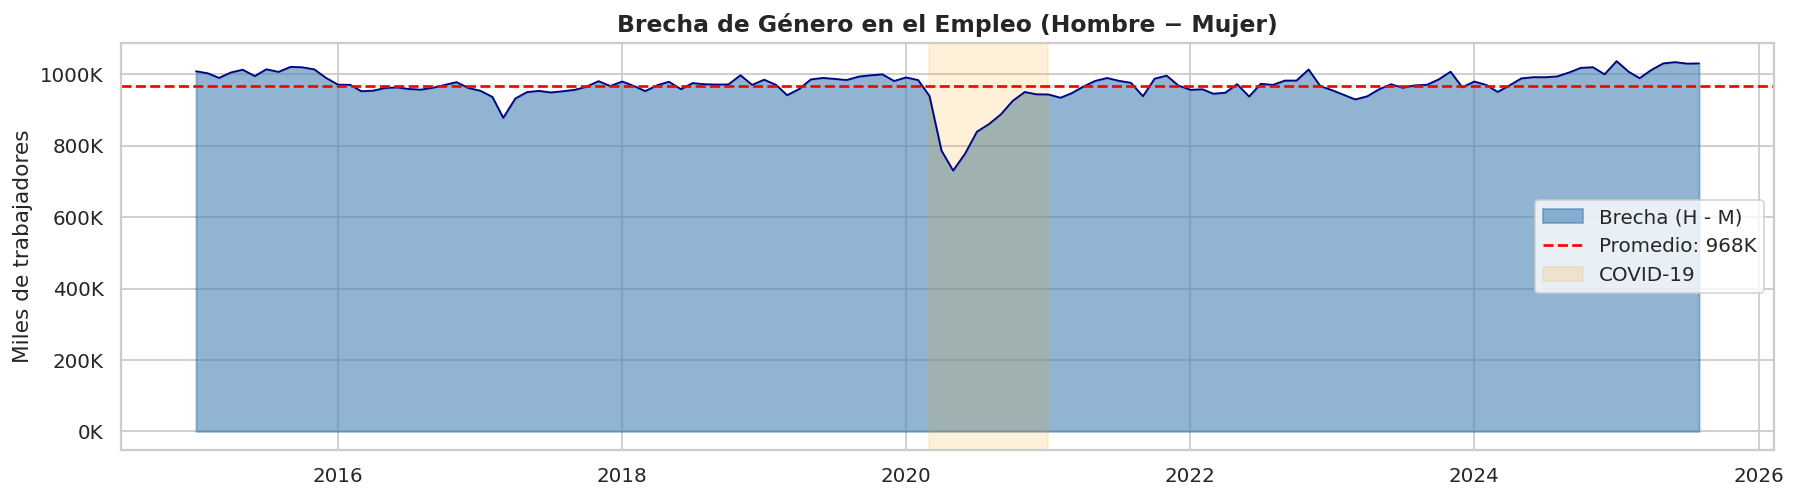

In [9]:
df['brecha'] = df['hombre'] - df['mujer']
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df['fecha'], df['brecha']/1e3, alpha=0.6, color='steelblue', label='Brecha (H - M)')
ax.plot(df['fecha'], df['brecha']/1e3, color='navy', lw=1)
ax.axhline(df['brecha'].mean()/1e3, color='red', ls='--', lw=1.5,
           label=f'Promedio: {df["brecha"].mean()/1e3:.0f}K')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'), alpha=0.15, color='orange', label='COVID-19')
ax.set_title('Brecha de Género en el Empleo (Hombre − Mujer)', fontsize=13, fontweight='bold')
ax.set_ylabel('Miles de trabajadores')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Promedio Anual y Tendencia

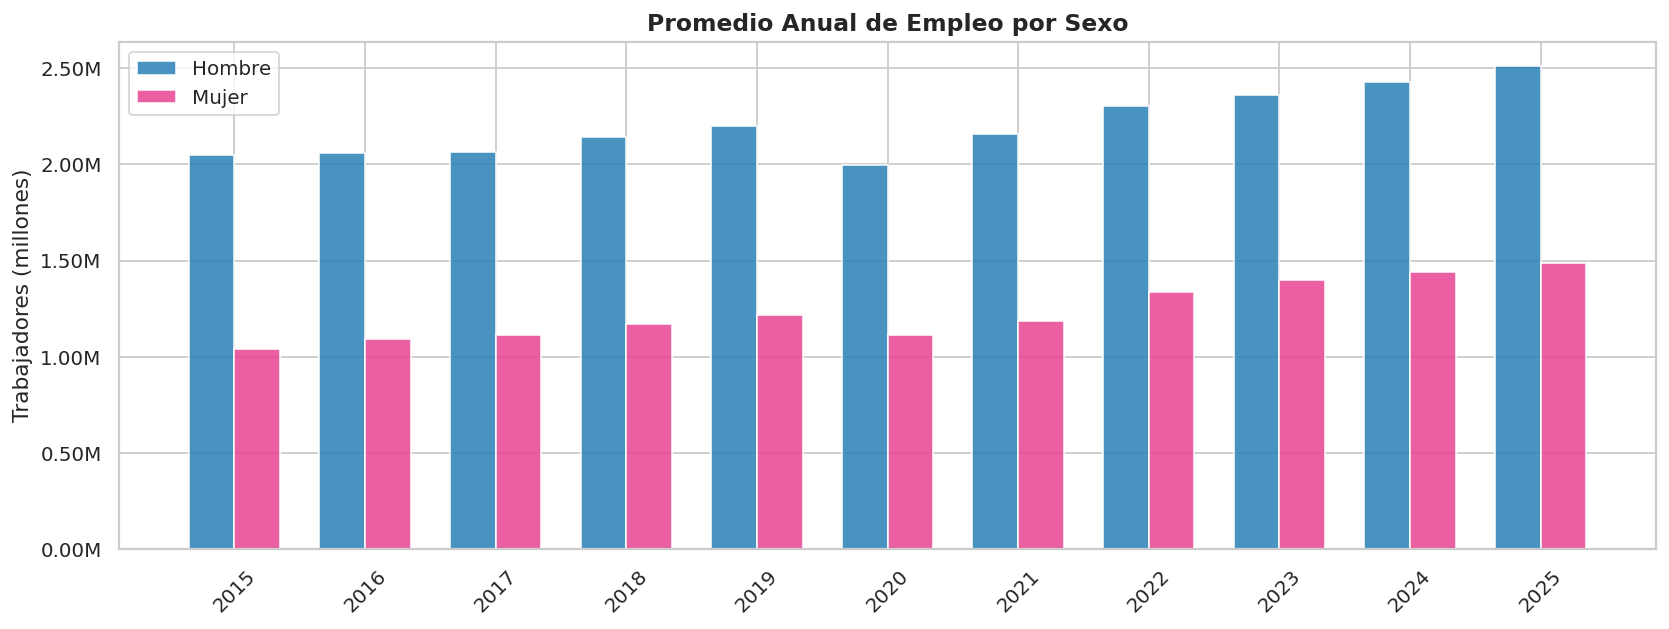

In [10]:
anual = df.groupby('anio')[['hombre','mujer']].mean().reset_index()
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(anual))
w = 0.35
ax.bar(x - w/2, anual['hombre']/1e6, w, label='Hombre', color=COLORS['hombre'], alpha=0.85)
ax.bar(x + w/2, anual['mujer']/1e6, w, label='Mujer', color=COLORS['mujer'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(anual['anio'].astype(int), rotation=45)
ax.set_title('Promedio Anual de Empleo por Sexo', fontsize=13, fontweight='bold')
ax.set_ylabel('Trabajadores (millones)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
ax.legend()
plt.tight_layout()
plt.show()

## 7. Mapa de Calor — Empleo Femenino

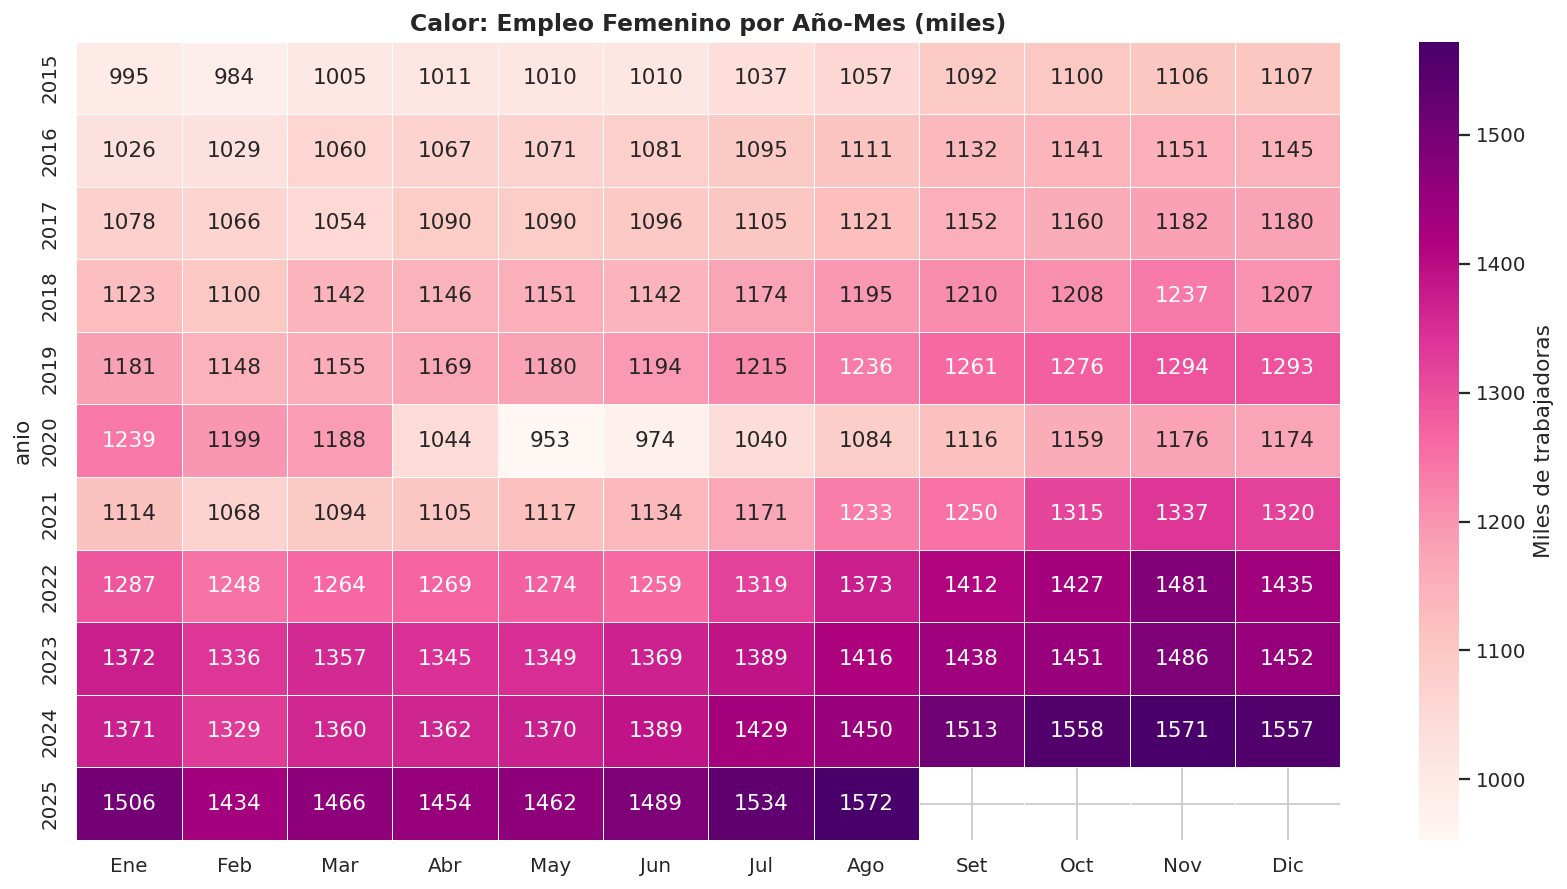

In [11]:
pivot = df.pivot_table(index='anio', columns='mes_num', values='mujer', aggfunc='mean')
pivot.columns = MESES_ETQ[:len(pivot.columns)]
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot/1e3, annot=True, fmt='.0f', cmap='RdPu',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Miles de trabajadoras'})
ax.set_title('Calor: Empleo Femenino por Año-Mes (miles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Estacionalidad por Sexo

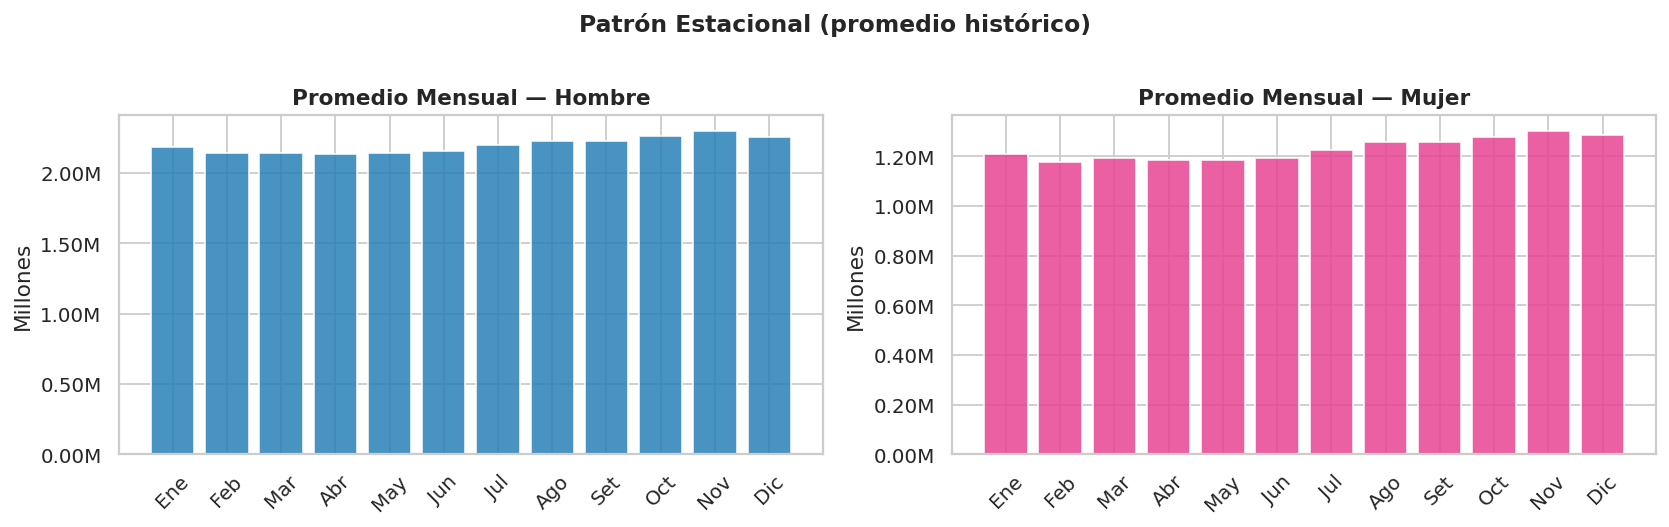

In [12]:
estac = df.groupby('mes_num')[['hombre','mujer']].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, titulo in zip(axes,
    ['hombre','mujer'], [COLORS['hombre'], COLORS['mujer']], ['Hombre','Mujer']):
    ax.bar(range(1,13), estac[col]/1e6, color=color, alpha=0.85)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MESES_ETQ, rotation=45)
    ax.set_title(f'Promedio Mensual — {titulo}', fontweight='bold')
    ax.set_ylabel('Millones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
plt.suptitle('Patrón Estacional (promedio histórico)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Boxplot por Año

/tmp/ipykernel_2595398/2170379870.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, patch_artist=True, labels=sorted(df['anio'].unique()))
/tmp/ipykernel_2595398/2170379870.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, patch_artist=True, labels=sorted(df['anio'].unique()))


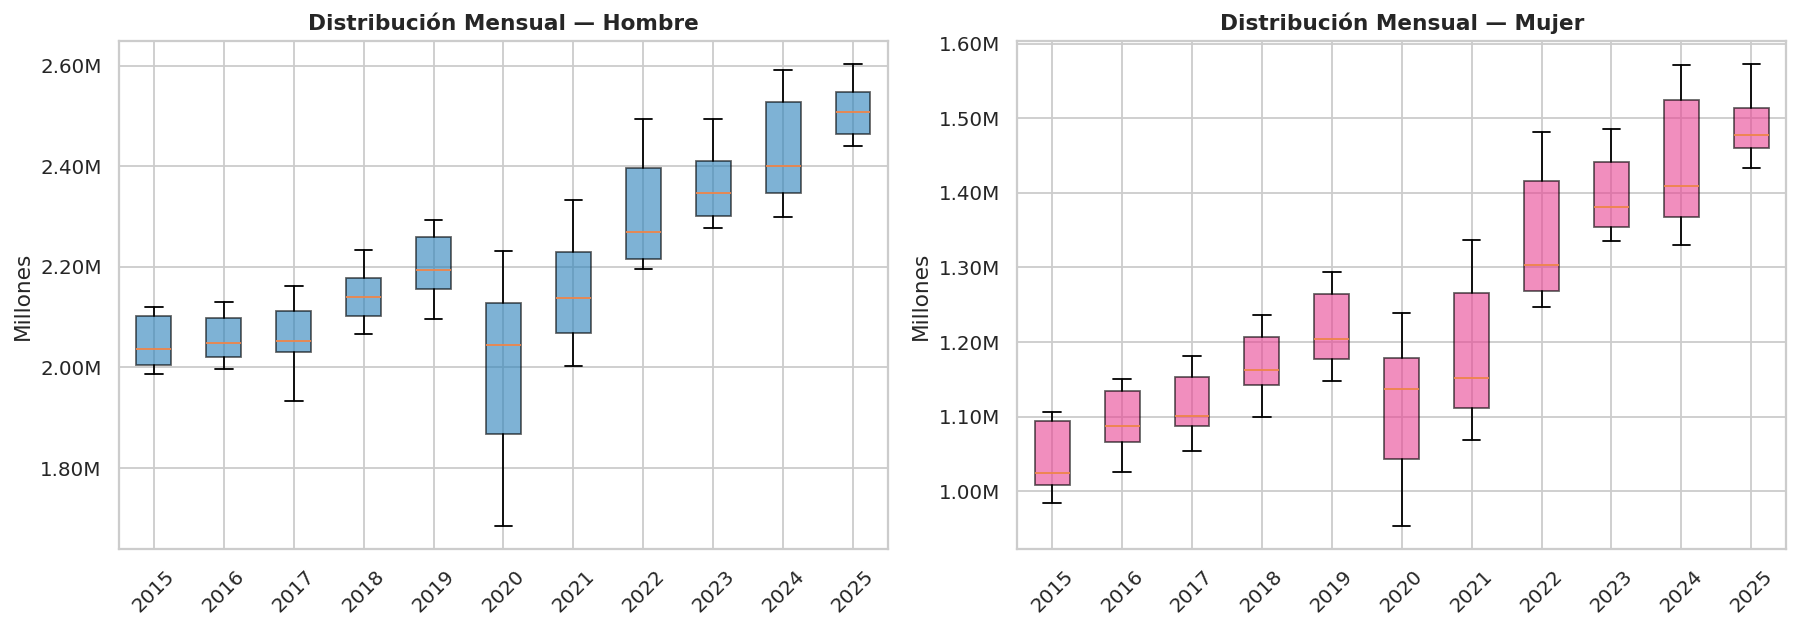

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, col, color, titulo in zip(axes,
    ['hombre','mujer'], [COLORS['hombre'], COLORS['mujer']], ['Hombre','Mujer']):
    data_by_year = [df[df['anio']==y][col].values/1e6 for y in sorted(df['anio'].unique())]
    bp = ax.boxplot(data_by_year, patch_artist=True, labels=sorted(df['anio'].unique()))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(sorted(df['anio'].unique()), rotation=45)
    ax.set_title(f'Distribución Mensual — {titulo}', fontweight='bold')
    ax.set_ylabel('Millones')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}M'))
plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

| Métrica | Hombre | Mujer |
|---------|--------|-------|
| Promedio mensual | ~2,168 K | ~1,208 K |
| Máximo | ~2,603 K (Ago 2025) | ~1,572 K (Nov 2024) |
| Mínimo | ~1,684 K (May 2020) | ~953 K (May 2020) |
| Participación promedio | ~64% | ~36% |

**Observaciones clave:**
- La **brecha de género** es persistente: los hombres representan ~64% del empleo privado dependiente.
- La brecha se **redujo ligeramente** entre 2020 y 2023, pero se mantuvo estable en ~800–900K.
- El **empleo femenino** creció más rápido porcentualmente en el período 2021–2025.
- El **COVID-19** impactó ambos sexos similarmente en términos relativos (~15–20% de caída).